In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import os

from spatioev.qc import run_segmentation_qc, filter_segmentation_errors
from spatioev.config import QCConfig
from spatioev.plot import plot_area_distribution, plot_nc_ratio_distribution

In [2]:
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

In [3]:
data_path = "data/exp_1.h5ad"
assert os.path.exists(data_path), "exp_1.h5ad not found."
adata = ad.read_h5ad(data_path)
adata

AnnData object with n_obs × n_vars = 51932 × 25
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractal_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'CD11c_nuclear', 'CD14_nuclear', 'CD146_nuclear', 'CD19_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD4_nuclear', 'CD45_nuclear', 'CD68_nuclear', 'CD90_nuclear', 'CK19_nuclear', 'COL1A1_nuclear', 'COL4A1_nuclear', 'COL6A1_nuclear', 'FN_nuclear', 'HLADR_nuclear', 'IGFBP5_nuclear', 'NaKATPase_nuclear', 'PCK_nuclear', 'PDPN_nuclear', 'RS6_nuclear', 'SMA_nuclear', 'Tenascin_nuclear', 'Vimentin_nuclear', 'dapi_nuclear', 'label_nuclear', 'area_nuclear', 'eccentricity_nuclear', 'major_axis_length_nuclear', 'min

In [4]:
required_columns = ["area", "nc_ratio"]
for col in required_columns:
    assert col in adata.obs.columns, f"Missing required column: {col}"
print("Required QC columns present.")

Required QC columns present.


In [5]:
config = QCConfig(
    pixel_size=0.325,
    min_area_um2=10,
    max_area_um2=1000,
    max_nc_ratio=1.0
)

adata_qc = run_segmentation_qc(adata.copy(), config)

adata_qc.obs.head()

,label,area,eccentricity,major_axis_length,minor_axis_length,perimeter,convex_area,equivalent_diameter,orientation,solidity,...,circularity_nuclear,fractal_dimension_nuclear,boundary_irregularity_nuclear,nc_ratio_nuclear,fov,mask_type,imageid,area_um2,area_category,nc_ratio_category
exp_0,1,446.0,0.512372,25.777519,22.136799,80.384776,462.0,23.829915,-1.495626,0.965368,...,0.820165,0.711299,3.819684,1.430493,fov1,whole_cell,exp,47.108750,normal_area,abnormal_nc_ratio
exp_1,2,137.0,0.496344,14.233404,12.356387,43.313708,147.0,13.207340,-1.313869,0.931973,...,0.894751,0.773619,3.619565,0.912409,fov1,whole_cell,exp,14.470625,normal_area,normal_nc_ratio
exp_2,3,620.0,0.551356,31.252725,26.073218,100.870058,664.0,28.096415,-0.268971,0.933735,...,0.785854,0.711066,3.896081,1.146774,fov1,whole_cell,exp,65.487500,normal_area,abnormal_nc_ratio
exp_3,4,1109.0,0.421413,40.600252,36.819096,141.112698,1223.0,37.576890,-0.725114,0.906787,...,0.701502,0.695164,4.123428,1.464382,fov1,whole_cell,exp,117.138125,normal_area,abnormal_nc_ratio
exp_4,5,683.0,0.749652,36.456042,24.127765,108.941125,727.0,29.489364,-0.974425,0.939477,...,0.762013,0.714630,3.936454,1.002928,fov1,whole_cell,exp,72.141875,normal_area,abnormal_nc_ratio


In [6]:
print("Area categories:")
print(adata_qc.obs["area_category"].value_counts())

print("\nNC ratio categories:")
print(adata_qc.obs["nc_ratio_category"].value_counts())

Area categories:
area_category
normal_area        51143
debris_fragment      789
Name: count, dtype: int64

NC ratio categories:
nc_ratio_category
normal_nc_ratio      48134
abnormal_nc_ratio     3798
Name: count, dtype: int64


In [7]:
adata_filtered = filter_segmentation_errors(adata_qc)

print("Original cells:", adata_qc.n_obs)
print("Filtered cells:", adata_filtered.n_obs)

print("Cells removed:", adata_qc.n_obs - adata_filtered.n_obs)

Original cells: 51932
Filtered cells: 47628
Cells removed: 4304


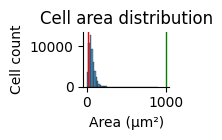

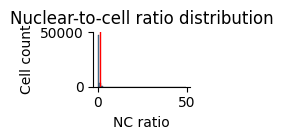

In [8]:
plot_area_distribution(
    adata_qc,
    min_area=config.min_area_um2,
    max_area=config.max_area_um2
)

plot_nc_ratio_distribution(
    adata_qc,
    max_ratio=config.max_nc_ratio
)

In [10]:
from spatioev.qc import generate_qc_summary

summary = generate_qc_summary(adata_qc)
summary

,total_cells,normal_cells,debris_fragment,merged_cell,abnormal_nc_ratio,removed_total,percent_removed
0,51932,47345,789,0,3798,4587,8.83
